In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import sys
import tensorflow

In [2]:
img = np.load('/pbs/home/b/barcelin/sps_link/data/psf_change/10_test/test/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

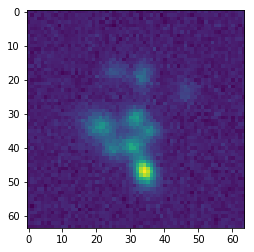

In [5]:
plt.imshow(img[3,-1,6])

In [6]:
img = np.load('/pbs/home/b/barcelin/sps_link/data/psf_change/1_6_test/test/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

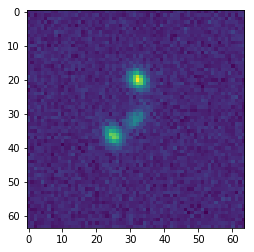

In [11]:
plt.imshow(img[3,-1,6])

In [2]:
sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import generator, utils

W1009 19:00:32.742956 139644849846080 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:65: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
nb_of_bands = 6#1
batch_size = 128

input_shape = (64, 64, nb_of_bands)
hidden_dim = 256
latent_dim = 32
final_dim = 2
filters = [32,64,128,256]#,512]
kernels = [5,4,3,3]#,3]

conv_activation = None
dense_activation = None

steps_per_epoch = int(10000/batch_size)
validation_steps = int(2000/batch_size)

bands = [4,5,6,7,8,9]#
#bands = [6]

In [4]:
images_dir = '/pbs/home/b/barcelin/sps_link/data/psf_change/1_6_test/'
list_of_samples = [[x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('.npy')][0]]#training

In [5]:
training_generator = generator.BatchGenerator_random_coord_psf(bands,
                                    images_dir,
                                    list_of_samples, 
                                    total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='test',
                                    do_norm=False,
                                    denorm = False,
                                    list_of_weights_e=None)

[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [15]:
gen = training_generator.__getitem__(2)

1
-1.577097308863737 -2.1869658389186584
4
-1.014940718745207 0.999527123527967
0
0.0 0.0
0
0.0 0.0
3
-1.005458458386368 -1.991527206106097
1
-0.9558995864967095 2.4155097222382613
0
0.0 0.0
1
0.6204942120394081 0.45285768912461943
3
2.2034889786989496 0.36175314100675404
2
-2.1339000393368033 -1.0802654621521754
4
-0.4339339242104119 -0.8827268392037633
3
1.2228114437826987 -1.132835341823097
1
-0.6188083030887297 2.6530945653813474
1
-2.9636989864523997 2.077248779972078
2
2.962496639673369 2.411516818565067
1
-3.1906882671766077 -0.9272703466310133
2
-2.836758748050061 2.8335703786238824
1
2.221886839287018 0.781299074969573
2
-0.9915810393049149 -2.256234194117006
1
-2.943105157224632 1.089235610747937
3
0.2806380041656631 1.8510203858214638
2
2.1644146895650023 0.8405839730793812
1
0.5451539622712573 2.7882591153151983
4
0.4288077493914848 3.0939028393448558
0
0.0 0.0
3
-1.3958577139625257 -1.6162649984824364
3
-2.3892156749611986 -1.679124686557978
1
-0.44468216257129267 -2.72270

In [16]:
gen[0][0].shape

(128, 64, 64, 6)

array([0.45095902, 0.2694022 ])

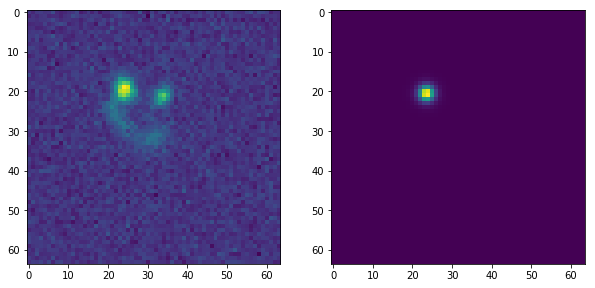

In [17]:
fig, axes = plt.subplots(1,2,figsize = (10,5))
axes[0].imshow(gen[0][0][0,:,:,2])
axes[1].imshow(gen[0][1][0,:,:,2])
gen[1][0]

In [16]:
for i in range (100):
    print(np.random.random_integers(2))

2
1
1
2
1
2
2
1
2
2
1
2
1
2
2
1
1
2
2
2
2
1
1
1
1
1
2
1
1
2
2
1
1
2
2
1
2
1
1
2
1
2
2
1
1
2
2
1
1
2
2
2
1
1
1
2
2
2
1
1
2
1
1
1
2
2
1
2
2
2
1
1
1
2
1
2
2
2
1
1
1
1
1
2
1
2
2
2
2
1
1
2
1
1
1
2
1
1
2
1


/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:2: DeprecationWarning: This function is deprecated. Please call randint(1, 2 + 1) instead
  


In [2]:
data_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random'
data_dir_test = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/test/'
root = 'galaxies_blended_20191024'

In [3]:
dfs = []

dfs.append(pd.read_csv(os.path.join(data_dir_test, root+'_0_data.csv')))
df = dfs[0]

for df2 in dfs[1:]:
    df = df.append(df2)

In [4]:
test_img = np.load(data_dir+'/test/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')
training_img = np.load(data_dir+'/training/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

test_data = pd.read_csv(data_dir+'/test/galaxies_blended_20191024_0_data_classified.csv')
training_data = pd.read_csv(data_dir+'/training/galaxies_blended_20191024_0_data_classified.csv')

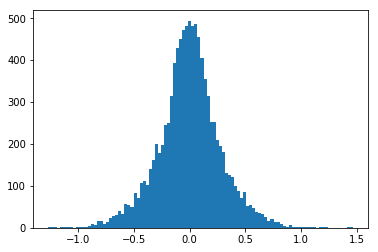

In [6]:
_ = plt.hist(test_data['e1_0'], bins = 100)

In [8]:
from scipy.stats import norm
# Fit a normal distribution to the data:
mu, std = norm.fit(test_data['e1_0'])
print(mu, std)

-0.0006810325532907882 0.27972312880305217


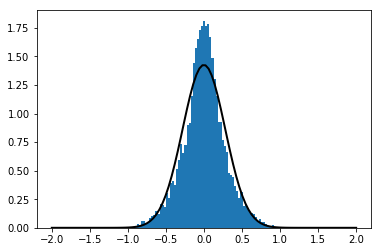

In [14]:
xmin, xmax = (-2,2)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

_ = plt.hist(test_data['e1_0'], bins = 100, normed = True)

-0.0016197468011117963 0.2805471962898235


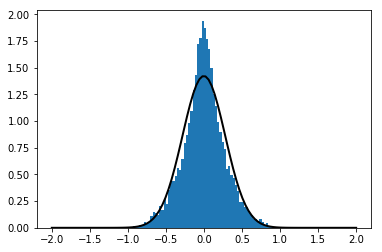

In [17]:
# Fit a normal distribution to the data:
mu, std = norm.fit(test_data['e2_0'])
print(mu, std)

xmin, xmax = (-2,2)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

_ = plt.hist(test_data['e2_0'], bins = 100, normed = True)

0.8119855671599507 0.6606203178820458


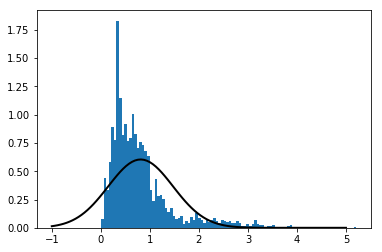

In [21]:
# Fit a normal distribution to the data:
mu, std = norm.fit(test_data['redshift_0'])
print(mu, std)

xmin, xmax = (-1,5)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

_ = plt.hist(test_data['redshift_0'], bins = 100, normed = True)

-0.4894036491965116 0.7709336177955792


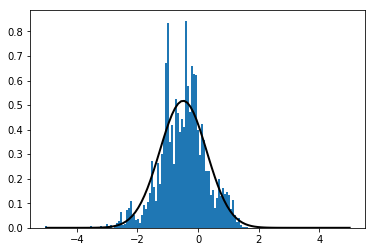

In [28]:
# Fit a normal distribution to the data:
mu, std = norm.fit(np.log(test_data['redshift_0']))
print(mu, std)

xmin, xmax = (-5,5)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

_ = plt.hist(np.log(test_data['redshift_0']), bins = 100, normed = True)

In [26]:
np.mean(test_data['redshift_0']-mu)

-3.481659405224491e-17

-1.1368683772161604e-17 1.0


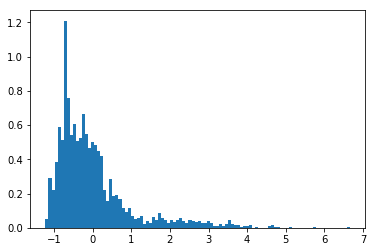

In [23]:
mu_2, std_2 = norm.fit((test_data['redshift_0']-mu)/std)
print(mu_2, std_2)

_ = plt.hist((test_data['redshift_0']-mu)/std, bins = 100, normed = True)

-6.3948846218409015e-18 1.0 5.8619775700208265e-18 1.0 -2.913225216616411e-17 1.0


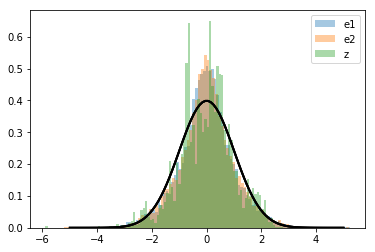

In [43]:
mu_e1, std_e1 = -0.0006810325532907882, 0.27972312880305217#norm.fit(new_data['e1_0'])
mu_e2, std_e2 = -0.0016197468011117963, 0.2805471962898235#norm.fit(new_data['e2_0'])
mu_z, std_z = -0.4894036491965116, 0.7709336177955792#norm.fit(np.log(new_data['redshift_0']))

_ = plt.hist((np.array(test_data['e1_0'])-mu_e1)/std_e1, bins = 100, alpha = 0.4, normed = True, label = 'e1')
_ = plt.hist((np.array(test_data['e2_0'])-mu_e2)/std_e2, bins = 100, alpha = 0.4, normed = True, label = 'e2')
_ = plt.hist((np.log(np.array(test_data['redshift_0']))-mu_z)/std_z, bins = 100, alpha = 0.4, normed = True, label = 'z')


mu_e1_2, std_e1_2 = norm.fit((np.array(test_data['e1_0'])-mu_e1)/std_e1)
mu_e2_2, std_e2_2 = norm.fit((np.array(test_data['e2_0'])-mu_e2)/std_e2)
mu_z_2, std_z_2 = norm.fit((np.log(np.array(test_data['redshift_0']))-mu_z)/std_z)
print(mu_e1_2, std_e1_2, mu_e2_2, std_e2_2, mu_z_2, std_z_2)

xmin, xmax = (-5,5)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu_e1_2, std_e1_2)
plt.plot(x, p, 'k', linewidth=2)

xmin, xmax = (-5,5)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu_e2_2, std_e2_2)
plt.plot(x, p, 'k', linewidth=2)

xmin, xmax = (-5,5)
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu_z_2, std_z_2)
plt.plot(x, p, 'k', linewidth=2)

plt.legend()

In [44]:
nmax_blend=1

In [45]:
np.max(1,nmax_blend[1])

TypeError: 'int' object is not subscriptable

In [10]:
test_img.shape, training_img.shape

((10000, 2, 10, 64, 64), (10000, 2, 10, 64, 64))

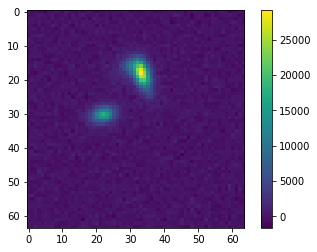

In [11]:
plt.imshow(test_img[3,1,6])
plt.colorbar()

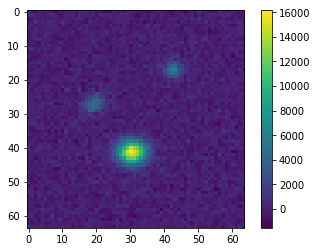

In [9]:
plt.imshow(training_img[3,1,6])
plt.colorbar()

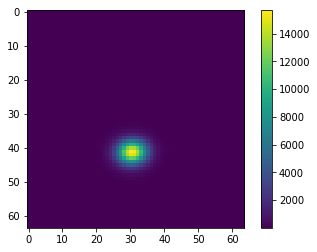

In [10]:
plt.imshow(training_img[3,0,6])
plt.colorbar()

In [11]:
shifts = np.load('/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_0_shifts.npy')

In [12]:
shifts.shape

(10000, 4, 2)

In [13]:
def listdir_fullpath(d):
    return [os.path.join(d, f) for f in os.listdir(d)]

In [14]:
list_of_shifts = [x for x in listdir_fullpath(os.path.join(data_dir,'training','shifts')) if x.endswith('.npy')]

In [15]:
list_of_shifts

['/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_4_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_0_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_7_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_9_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_2_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_8_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/shifts/galaxies_blended_20191024_5_shifts.npy',
 '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/random/training/

In [16]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
Unnamed: 0    10000 non-null int64
redshift_0    10000 non-null float64
e1_0          10000 non-null float64
e2_0          10000 non-null float64
mag_0         10000 non-null float64
redshift_1    10000 non-null float64
e1_1          10000 non-null float64
e2_1          10000 non-null float64
mag_1         10000 non-null float64
redshift_2    10000 non-null float64
e1_2          10000 non-null float64
e2_2          10000 non-null float64
mag_2         10000 non-null float64
redshift_3    10000 non-null float64
e1_3          10000 non-null float64
e2_3          10000 non-null float64
mag_3         10000 non-null float64
dtypes: float64(16), int64(1)
memory usage: 1.3 MB


In [17]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
Unnamed: 0    10000 non-null int64
redshift_0    10000 non-null float64
e1_0          10000 non-null float64
e2_0          10000 non-null float64
mag_0         10000 non-null float64
redshift_1    10000 non-null float64
e1_1          10000 non-null float64
e2_1          10000 non-null float64
mag_1         10000 non-null float64
redshift_2    10000 non-null float64
e1_2          10000 non-null float64
e2_2          10000 non-null float64
mag_2         10000 non-null float64
redshift_3    10000 non-null float64
e1_3          10000 non-null float64
e2_3          10000 non-null float64
mag_3         10000 non-null float64
dtypes: float64(16), int64(1)
memory usage: 1.3 MB


In [20]:
np.where(training_data['redshift_1']!=0)[0].shape

(7562,)

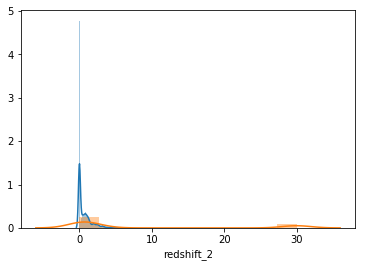

In [18]:
sns.distplot(test_data['redshift_2'])
sns.distplot(training_data['redshift_2'])

In [23]:
# Import necessary librairies

import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras
import sys
import os
import logging
import galsim
import random
import cmath as cm
import math
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import metrics
from tensorflow.keras.layers import Input, Dense, Lambda, Layer, Add, Multiply, Reshape, Flatten, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Conv2D, Input, Dense, Dropout, MaxPool2D, Flatten,  Reshape, UpSampling2D, Cropping2D, Conv2DTranspose, PReLU, Concatenate, Lambda, BatchNormalization, concatenate, LeakyReLU

import tensorflow_probability as tfp


from importlib import reload
import sys
import os
sys.path.insert(0,'../../../conditional_VAE/scripts/tools_for_VAE/')
import tools_for_VAE.layers as layers
from tools_for_VAE import utils, vae_functions, generator, model

In [24]:
class SampleMultivariateGaussian(Layer):
    """
    Samples from a multivariate Gaussian given a mean and a full covariance matrix or just diagonal std.
    """

    def __init__(self, full_cov, add_KL, return_KL, coeff_KL=1.0, *args, **kwargs):
        """
        full_cov: whether to use a full covariance matrix or just the diagonal.
        add_KL: boolean, whether to add the (sample average) KL divergence of the input distribution with respect to a standard Gaussian
        return_KL: whether to return the value of the KL divergence (one value per sample).
        """
        self.full_cov = full_cov
        self.add_KL = add_KL
        self.return_KL = return_KL
        self.coeff_KL = coeff_KL

        if full_cov:
            self.distrib = tfp.distributions.MultivariateNormalFullCovariance
        else:
            self.distrib = tfp.distributions.MultivariateNormalDiag

        super(SampleMultivariateGaussian,
              self).__init__(*args, **kwargs)

    def call(self, inputs):
        """
        inputs = if full_cov is True, [mu, cov] where mu is the mean vector and cov the covariance matrix, otherwise [mu,sigma] where sigma is the std.
        """
        if self.full_cov:
            z_mu, z_cov = inputs
            dist_z = self.distrib(loc=z_mu, covariance_matrix=z_cov)
            dist_0 = self.distrib(
                loc=tf.zeros_like(z_mu), covariance_matrix=tf.identity(z_cov))

        else:
            z_mu, z_sigma = inputs
            dist_z = self.distrib(loc=z_mu, scale_diag=z_sigma)
            dist_0 = self.distrib(loc=tf.zeros_like(
                z_mu), scale_diag=tf.ones_like(z_sigma))

        z = dist_z.sample()
        
        if self.add_KL or self.return_KL:
            kl_divergence = tfp.distributions.kl_divergence(
                dist_z, dist_0, name='KL_divergence_full_cov')
            if self.add_KL:
                self.add_loss(self.coeff_KL*K.mean(kl_divergence), inputs=inputs)
            if self.return_KL:
                return z, kl_divergence

        return z

    def compute_output_shape(self, input_shape):
        """
        Same shape as the mean vector
        """
        return input_shape[0]


In [25]:
#### Create encooder
def build_model(latent_dim, hidden_dim, filters, kernels,nb_of_bands, conv_activation=None, dense_activation=None):#'sofplus'
    """
    Return encoder as model
    latent_dim : dimension of the latent variable
    hidden_dim : dimension of the dense hidden layer
    filters: list of the sizes of the filters used for this model
    list of the size of the kernels used for each filter of this model
    conv_activation: type of activation layer used after the convolutional layers
    dense_activation: type of activation layer used after the dense layers
    nb_of bands : nb of band-pass filters needed in the model
    """
    input_layer = Input(shape=(64,64,nb_of_bands))
    parameters = Input(shape=(3))
    input_shape = (64, 64, nb_of_bands)

    #h = Reshape((64,64,nb_of_bands))(input_layer)
    h = BatchNormalization()(input_layer)
    for i in range(len(filters)):
        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        h = PReLU()(h)
        #h = h + Conv2D(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        #h = PReLU()(h)
        #h = h + Conv2D(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        #h = PReLU()(h)

        h = Conv2D(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
    h = Flatten()(h)
    #h = tf.keras.layers.concatenate([h,parameters])
    #h = PReLU()(h)
    h = Dense(hidden_dim, activation=dense_activation)(h)
    h = PReLU()(h)
    #h = tf.keras.layers.concatenate([h,parameters])
    mu = Dense(latent_dim)(h)
    sigma = Dense(latent_dim, activation='softplus')(h)
    
    z, Dkl = SampleMultivariateGaussian(full_cov=False, add_KL=False, return_KL=True, coeff_KL=0)([mu, sigma])
    z_conc = tf.keras.layers.concatenate([z,parameters])

    h = Dense(hidden_dim, activation=dense_activation)(z_conc)
    h = PReLU()(h)
    w = int(np.ceil(input_shape[0]/2**(len(filters))))
    h = Dense(w*w*filters[-1], activation=dense_activation)(h)
    h = PReLU()(h)
    h = Reshape((w,w,filters[-1]))(h)
    for i in range(len(filters)-1,-1,-1):
        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same', strides=(2,2))(h)
        h = PReLU()(h)
        #h = h + Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        #h = PReLU()(h)
        #h = h + Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        #h = PReLU()(h)

        h = Conv2DTranspose(filters[i], (kernels[i],kernels[i]), activation=conv_activation, padding='same')(h)
        h = PReLU()(h)
    h = Conv2D(input_shape[-1], (3,3), activation=None, padding='same')(h)#'sigmoid'
    h = PReLU()(h)
    cropping = int(h.get_shape()[1]-input_shape[0])
    if cropping>0:
        print('in cropping')
        if cropping % 2 == 0:
            h = Cropping2D(cropping/2)(h)
        else:
            h = Cropping2D(((cropping//2,cropping//2+1),(cropping//2,cropping//2+1)))(h)

    return Model([input_layer,parameters], h) , Dkl

In [26]:
batch_size = 100
latent_dim = 32
epochs = 10
load = 'false'
bands = [4,5,6,7,8,9]
nb_of_bands = len(bands)
hidden_dim = 256
filters = [32, 64, 128, 256]#, 1024]
kernels = [3,3,3,3]#, 3]


vae, Dkl = build_model(latent_dim, hidden_dim, filters, kernels,nb_of_bands)

In [27]:
path_output = '/sps/lsst/users/barcelin/weights/c-VAE/mse/'
latest = tf.train.latest_checkpoint(path_output)
vae.load_weights(latest)

In [72]:
training_img[:100,0,4:].shape

(100, 6, 64, 64)

In [73]:
np.transpose(training_img[:100,0,4:], axes = (0,2,3,1)).shape

(100, 64, 64, 6)

In [69]:
reload(generator)

<module 'tools_for_VAE.generator' from '../../../conditional_VAE/scripts/tools_for_VAE/tools_for_VAE/generator.py'>

In [28]:
images_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/centered/'#random

list_of_samples = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('.npy')]#training
list_of_shifts = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test','shifts')) if x.endswith('.npy')]#training

list_of_samples_val = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test')) if x.endswith('.npy')]#validation
list_of_shifts_val = [x for x in utils.listdir_fullpath(os.path.join(images_dir,'test','shifts')) if x.endswith('.npy')]#validation

training_generator = generator.BatchGenerator(bands, list_of_samples, list_of_shifts, total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='test',#training
                                    do_norm=False,
                                    denorm = False,
                                    path = os.path.join(images_dir, "test/"),
                                    list_of_weights_e=None)

validation_generator = generator.BatchGenerator(bands, list_of_samples_val,list_of_shifts_val, total_sample_size=None,
                                    batch_size=batch_size, 
                                    trainval_or_test='test',#validation
                                    do_norm=False,
                                    denorm = False,
                                    path = os.path.join(images_dir, "test/"),
                                    list_of_weights_e= None)

[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1
[BatchGenerator] total_sample_size =  10000
[BatchGenerator] len(list_of_samples) =  1


In [29]:
img = training_generator.__getitem__(2)

In [30]:
#img[2]

In [31]:
shifts = np.load('/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/centered/test/shifts/galaxies_blended_20191024_0_shifts.npy', mmap_mode = 'c')

In [27]:
shifts[5877, 0]

memmap([0., 0.])

In [28]:
img[0][0].shape, img[0][1].shape

((100, 64, 64, 6), (100, 3))

In [29]:
img[0][1][0]

array([-0.03951585, -0.13696091,  0.40329999])

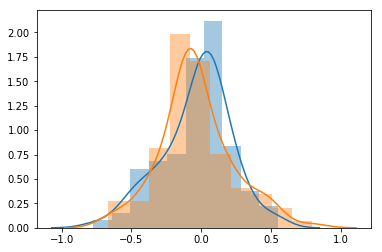

In [30]:
sns.distplot(img[0][1][:,0], bins = 10)
sns.distplot(img[0][1][:,1], bins = 10)

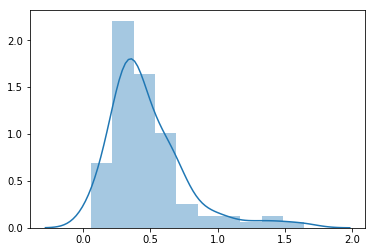

In [31]:
sns.distplot(img[0][1][:,2], bins = 10)

In [32]:
sns.distplot(img[0][1][:,3], bins = 10)
sns.distplot(img[0][1][:,4], bins = 10)

IndexError: index 3 is out of bounds for axis 1 with size 3

In [115]:
np.min(img[0][1][:,4])/0.2

-15.955700534245072

In [116]:
img[0][1][0,3], img[0][1][0,4]

(0.19210587282457592, 2.3984043017508636)

0
1
2
3
4
5
6
7
8
9


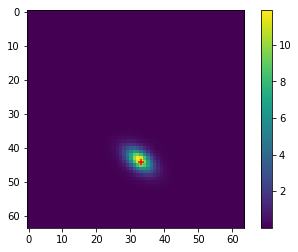

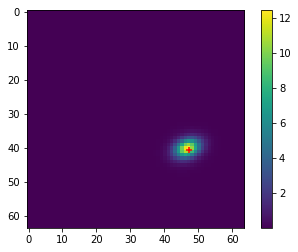

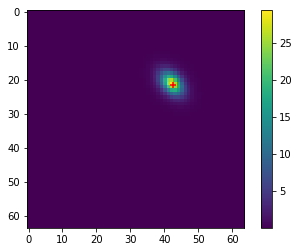

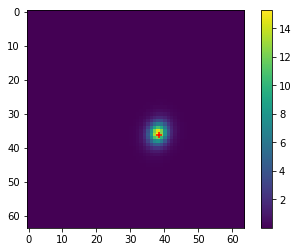

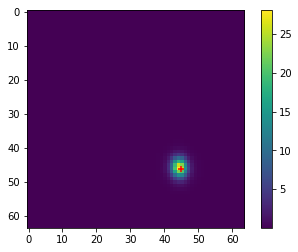

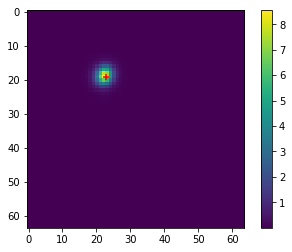

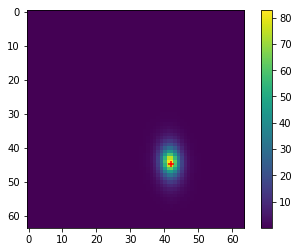

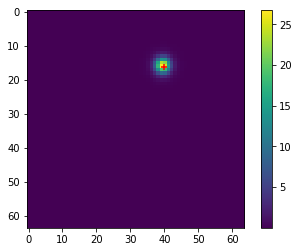

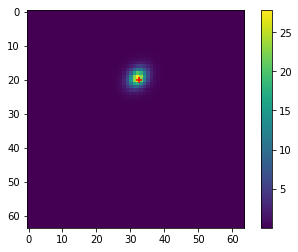

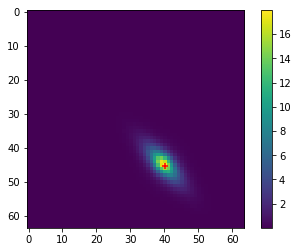

In [117]:
for i in range (10):
    print(i)
    fig = plt.figure()
    plt.imshow(img[0][0][i,:,:,2])
    plt.colorbar()
    plt.scatter((32+img[0][1][i,3]/0.2), (32+img[0][1][i,4]/0.2), c = 'r', marker = '+')

In [39]:
path_output = '/sps/lsst/users/barcelin/weights/c-VAE/mse/'
latest = tf.train.latest_checkpoint(path_output)
vae.load_weights(latest)

In [46]:
out = vae(img[0])

In [47]:
out.shape

TensorShape([100, 64, 64, 6])

In [48]:
np.max(out)

281.86737

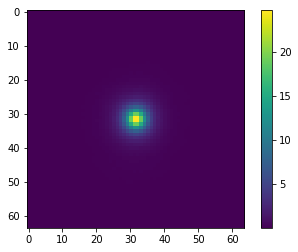

In [49]:
plt.imshow(out[0,:,:,2])
plt.colorbar()

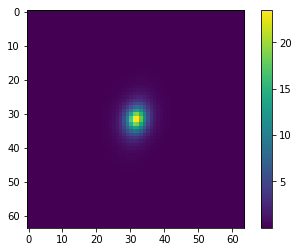

In [50]:
plt.imshow(img[0][0][0,:,:,2])
plt.colorbar()

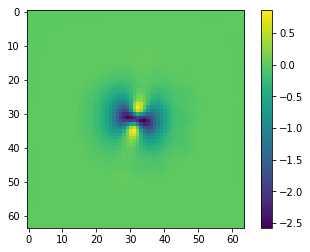

In [38]:
plt.imshow(img[0][0][0,:,:,2]-out[0,:,:,2])
plt.colorbar()

In [3]:
data_dir = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/centered'
data_dir_test = '/sps/lsst/users/barcelin/data/TFP/GalSim_COSMOS/blended_galaxies/centered/test/'

root = 'galaxies_blended_20191024'

dfs = []

dfs.append(pd.read_csv(os.path.join(data_dir_test, root+'_0_data.csv')))

df = dfs[0]

for df2 in dfs[1:]:

    df = df.append(df2)

test_img = np.load(data_dir+'/test/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')
#training_img = np.load(data_dir+'/training/galaxies_blended_20191024_0_images.npy', mmap_mode = 'c')

#test_data = pd.read_csv(data_dir+'/test/galaxies_blended_20191024_0_data_classified.csv')
#training_data = pd.read_csv(data_dir+'/training/galaxies_blended_20191024_0_data_classified.csv')

In [4]:
test_img.shape

(10000, 2, 10, 64, 64)

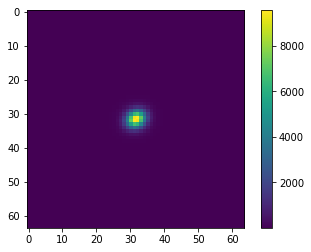

In [5]:
plt.imshow(test_img[0,0,6])
plt.colorbar()

## Load data from generating DC2

In [2]:
sys.path.insert(0,'../../scripts/tools_for_VAE/')
from tools_for_VAE import plot
#%matplotlib widget

W1112 16:55:18.555917 140440321165120 deprecation.py:323] From /sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/tensorflow_core/python/compat/v2_compat.py:88: disable_resource_variables (from tensorflow.python.ops.variable_scope) is deprecated and will be removed in a future version.
Instructions for updating:
non-resource variables are not supported in the long term


In [3]:
img_gen = np.load('/sps/lsst/users/barcelin/data/dc2_test/training_2/1_img_sample.npy', mmap_mode = 'c')
psf_gen = np.load('/sps/lsst/users/barcelin/data/dc2_test/training_2/1_psf_sample.npy', mmap_mode = 'c')
data_gen = pd.read_csv('/sps/lsst/users/barcelin/data/dc2_test/training_2/1_img_data.csv')

e1: 0.08402904016031595
e2: -0.0005663292989776213
redshift: 0.8480285195337693
e1: 0.035991201255253624
e2: -0.026843051961971398
redshift: 2.5203535518054525
e1: -0.07860598852282445
e2: 0.1697718041935248
redshift: 0.5844362510464307


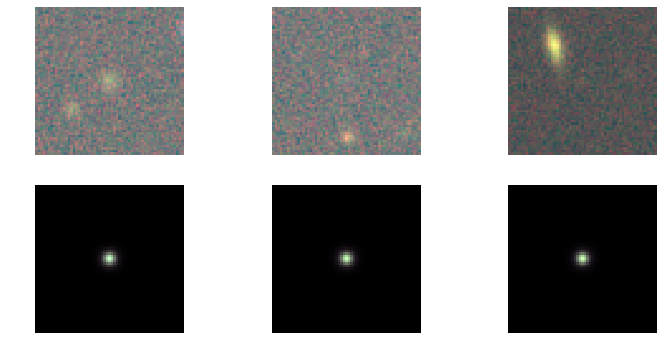

In [4]:
fig, axes  = plt.subplots(2,3, figsize = (12,6))

for i in range (3):
    # Image of galaxy scene
    img_gen[i+10] -= np.min(img_gen[i+10])
    plot.plot_rgb(img_gen[i+10]/np.max(img_gen[i+10]), bands=[4,3,1], ax=axes[0,i], band_first=False, zoom=1)
    # Corresponding PSF
    psf_gen[i+10] -= np.min(psf_gen[i+10])
    plot.plot_rgb(psf_gen[i+10]/np.max(psf_gen[i+10]), bands=[4,3,1], ax=axes[1,i], band_first=False, zoom=1)
    print('e1: '+str(data_gen['e1'][i+10]))
    print('e2: '+str(data_gen['e2'][i+10]))
    print('redshift: '+str(data_gen['redshift'][i+10]))

e1: 0.08402904016031595
e2: -0.0005663292989776213
redshift: 0.8480285195337693
SNR in r band: 24.56646995969327
e1: 0.035991201255253624
e2: -0.026843051961971398
redshift: 2.5203535518054525
SNR in r band: 13.44839573311733
e1: -0.07860598852282445
e2: 0.1697718041935248
redshift: 0.5844362510464307
SNR in r band: 7.1515837745862045


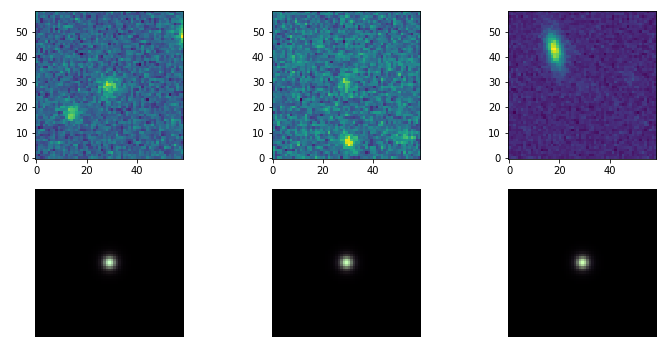

In [5]:
fig, axes  = plt.subplots(2,3, figsize = (12,6))

for i in range (3):
    # Image of galaxy scene
    img_gen[i+10] -= np.min(img_gen[i+10])
    axes[0,i].imshow(img_gen[i+10,:,:,2], origin = 'lower')
    #plot.plot_rgb(img_gen[i+10]/np.max(img_gen[i+10]), bands=[4,3,1], ax=axes[0,i], band_first=False, zoom=1)
    # Corresponding PSF
    psf_gen[i+10] -= np.min(psf_gen[i+10])
    plot.plot_rgb(psf_gen[i+10]/np.max(psf_gen[i+10]), bands=[4,3,1], ax=axes[1,i], band_first=False, zoom=1)
    print('e1: '+str(data_gen['e1'][i+10]))
    print('e2: '+str(data_gen['e2'][i+10]))
    print('redshift: '+str(data_gen['redshift'][i+10]))
    print('SNR in r band: '+str(data_gen['snr_r'][i+10]))

e1: 0.08402904016031595
e2: -0.0005663292989776213
redshift: 0.8480285195337693
SNR in r band: 24.56646995969327
e1: 0.035991201255253624
e2: -0.026843051961971398
redshift: 2.5203535518054525
SNR in r band: 13.44839573311733
e1: -0.07860598852282445
e2: 0.1697718041935248
redshift: 0.5844362510464307
SNR in r band: 7.1515837745862045


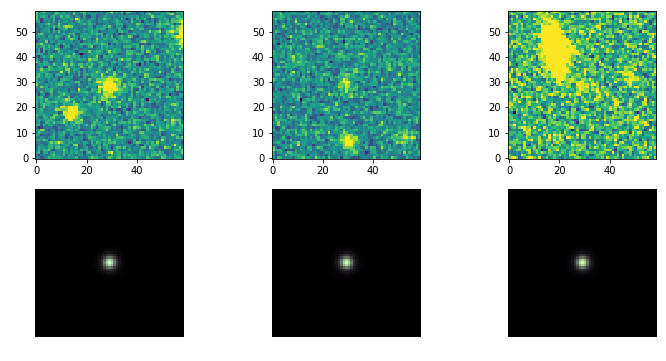

In [6]:
fig, axes  = plt.subplots(2,3, figsize = (12,6))

for i in range (3):
    # Image of galaxy scene
    img_gen[i+10] -= np.min(img_gen[i+10])
    axes[0,i].imshow(img_gen[i+10,:,:,2], origin = 'lower', vmax = 1)
    #plot.plot_rgb(img_gen[i+10]/np.max(img_gen[i+10]), bands=[4,3,1], ax=axes[0,i], band_first=False, zoom=1)
    # Corresponding PSF
    psf_gen[i+10] -= np.min(psf_gen[i+10])
    plot.plot_rgb(psf_gen[i+10]/np.max(psf_gen[i+10]), bands=[4,3,1], ax=axes[1,i], band_first=False, zoom=1)
    print('e1: '+str(data_gen['e1'][i+10]))
    print('e2: '+str(data_gen['e2'][i+10]))
    print('redshift: '+str(data_gen['redshift'][i+10]))
    print('SNR in r band: '+str(data_gen['snr_r'][i+10]))

In [7]:
data_gen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
id               10000 non-null int64
e1               10000 non-null float64
e2               10000 non-null float64
shear_1          10000 non-null float64
shear_2          10000 non-null float64
redshift         10000 non-null float64
redshift_true    10000 non-null float64
blendedness      9978 non-null float64
snr_r            9996 non-null float64
convergence      10000 non-null float64
dtypes: float64(9), int64(1)
memory usage: 781.3 KB


minimum snr = 6.0944632977248405


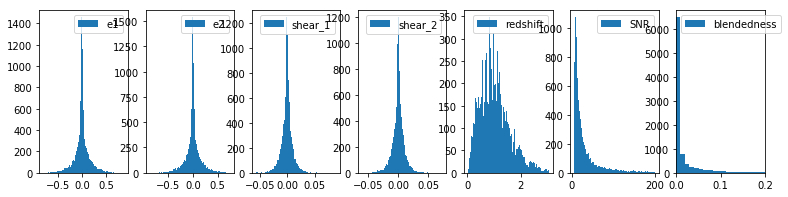

In [8]:
fig, axes = plt.subplots(1,7, figsize = (13,3))
_ = axes[0].hist(data_gen['e1'], bins = 100, label = 'e1')
_ = axes[1].hist(data_gen['e2'], bins = 100, label = 'e2')
_ = axes[2].hist(data_gen['shear_1'], bins = 100, label = 'shear_1')
_ = axes[3].hist(data_gen['shear_2'], bins = 100, label = 'shear_2')
_ = axes[4].hist(data_gen['redshift'], bins = 100, label = 'redshift')
data_new = data_gen[(np.abs(data_gen['e1'])<=1.) &
                (np.abs(data_gen['e2'])<=1.) &
                (data_gen['snr_r']<200)]
_ = axes[5].hist(data_new['snr_r'], bins = 100, label = 'SNR')
_ = axes[6].hist(data_new['blendedness'], bins = 100, label = 'blendedness')
axes[6].set_xlim(0,0.2)

for i in range (7):
    axes[i].legend()
print('minimum snr = '+str(np.min(data_new['snr_r'])))

In [9]:
img_gen.shape

(10000, 59, 59, 6)

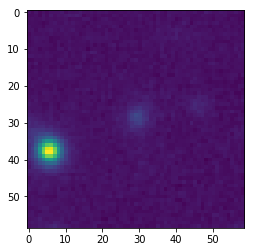

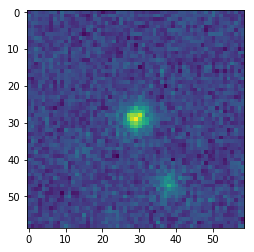

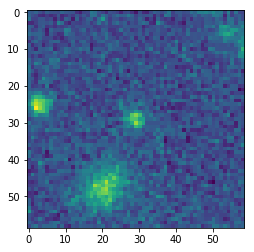

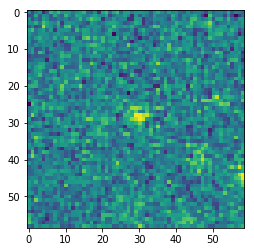

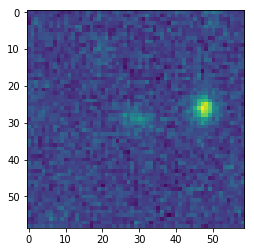

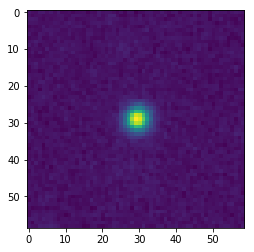

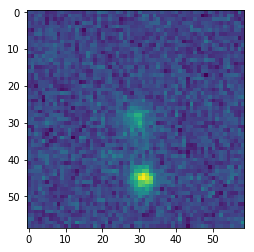

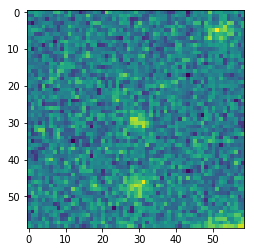

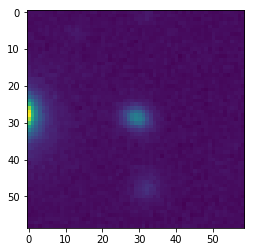

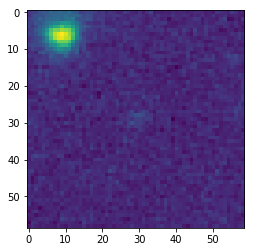

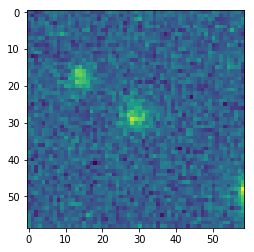

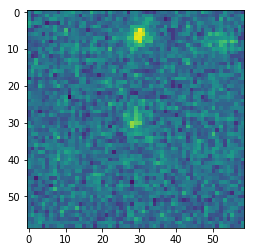

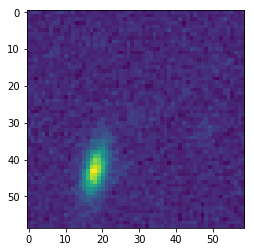

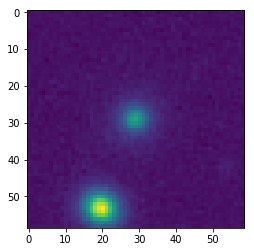

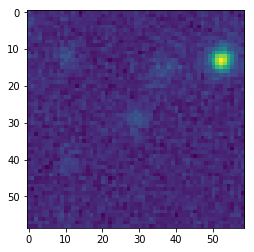

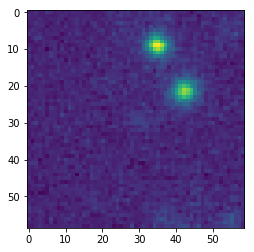

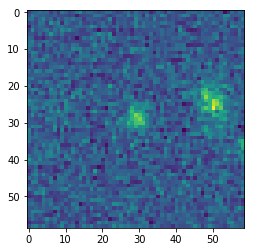

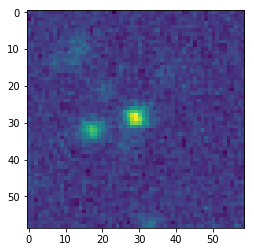

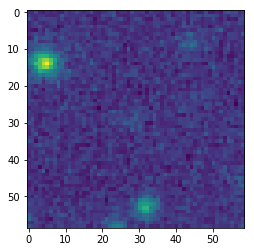

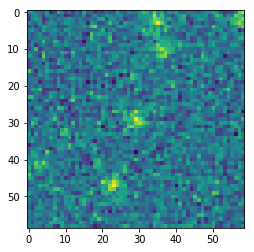

In [10]:
for i in range(20):
    fig = plt.figure()
    plt.imshow(img_gen[i,:,:,2])

In [11]:
img_gen = np.load('/sps/lsst/users/barcelin/data/dc2_test/training_mag_24.5/1_img_sample.npy', mmap_mode = 'c')
psf_gen = np.load('/sps/lsst/users/barcelin/data/dc2_test/training_mag_24.5/1_psf_sample.npy', mmap_mode = 'c')
data_gen = pd.read_csv('/sps/lsst/users/barcelin/data/dc2_test/training_mag_24.5/1_img_data.csv')

minimum snr = 41.87423469471752


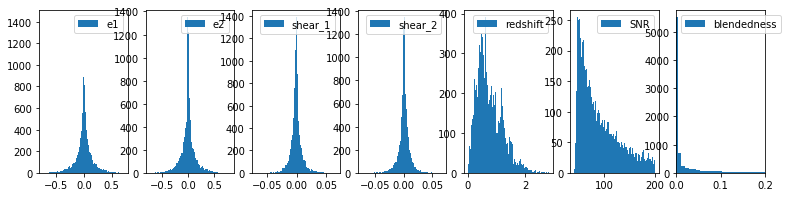

In [12]:
fig, axes = plt.subplots(1,7, figsize = (13,3))
_ = axes[0].hist(data_gen['e1'], bins = 100, label = 'e1')
_ = axes[1].hist(data_gen['e2'], bins = 100, label = 'e2')
_ = axes[2].hist(data_gen['shear_1'], bins = 100, label = 'shear_1')
_ = axes[3].hist(data_gen['shear_2'], bins = 100, label = 'shear_2')
_ = axes[4].hist(data_gen['redshift'], bins = 100, label = 'redshift')
data_new = data_gen[(np.abs(data_gen['e1'])<=1.) &
                (np.abs(data_gen['e2'])<=1.) &
                (data_gen['snr_r']<200)]
_ = axes[5].hist(data_new['snr_r'], bins = 100, label = 'SNR')
_ = axes[6].hist(data_new['blendedness'], bins = 100, label = 'blendedness')
axes[6].set_xlim(0,0.2)

for i in range (7):
    axes[i].legend()
print('minimum snr = '+str(np.min(data_new['snr_r'])))

In [13]:
import sklearn
from sklearn import preprocessing
from scipy.stats import norm
import matplotlib.mlab as mlab

In [14]:
## Compute lensed ellipticities from shear and 
def calc_lensed_ellipticity_1(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =  es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.real(e)

def calc_lensed_ellipticity_2(es1, es2, gamma1, gamma2, kappa):
    gamma = gamma1 + gamma2*1j # shear (as a complex number)
    es =   es1 + es2*1j # intrinsic ellipticity (as a complex number)
    g = gamma / (1.0 - kappa) # reduced shear
    e = (es + g) / (1.0 + g.conjugate()*es) # lensed ellipticity
    return np.imag(e)

In [15]:
ell_1 = np.array(data_gen['e1'])
ell_2 = np.array(data_gen['e2'])
shear_1 = np.array(data_gen['shear_1'])
shear_2 = np.array(data_gen['shear_2'])
convergence = np.array(data_gen['convergence'])

ellipticity_1 = calc_lensed_ellipticity_1(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_2 = calc_lensed_ellipticity_2(ell_1, ell_2, shear_1, shear_2, convergence)
ellipticity_conversion = lambda e: 2*e / (1.0+e*e)

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: scipy.stats.norm.pdf
  
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'densit

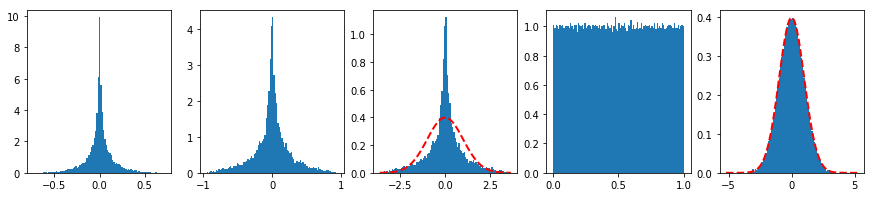

In [16]:
fig, axes = plt.subplots(1,5,figsize=(15,3))
_ = axes[0].hist(data_gen['e1'], bins = 100, label = 'e1', normed = True)
_ = axes[1].hist(ellipticity_conversion(ellipticity_1), bins = 100, label = 'e1', normed = True)
n, bins, patches = axes[2].hist(preprocessing.scale(ellipticity_conversion(ellipticity_1)), bins = 100, label = 'e1', normed = True)
(mu, sigma) = norm.fit(preprocessing.scale(ellipticity_conversion(ellipticity_1)))
z_plt = mlab.normpdf( bins, mu, sigma)
axes[2].plot(bins, z_plt, 'r--', linewidth=2)

quantile_transformer = preprocessing.QuantileTransformer(random_state=0) 
X_train_trans = quantile_transformer.fit_transform(ellipticity_conversion(ellipticity_1).reshape(-1, 1))
n, bins, patches = axes[3].hist(X_train_trans, bins = 100, label = 'e1', normed = True)

quantile_transformer = preprocessing.QuantileTransformer(output_distribution='normal',random_state=0) 
X_train_trans = quantile_transformer.fit_transform(ellipticity_conversion(ellipticity_1).reshape(-1, 1))
n, bins, patches = axes[4].hist(X_train_trans, bins = 100, label = 'e1', normed = True)
(mu, sigma) = norm.fit(X_train_trans)
z_plt = mlab.normpdf( bins, mu, sigma)
axes[4].plot(bins, z_plt, 'r--', linewidth=2)

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: scipy.stats.norm.pdf
  
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'densit

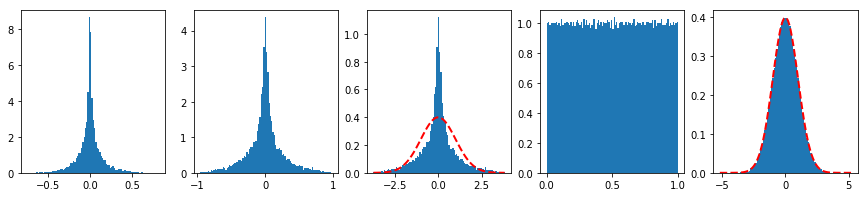

In [17]:
fig, axes = plt.subplots(1,5,figsize=(15,3))
_ = axes[0].hist(data_gen['e2'], bins = 100, label = 'e2', normed = True)
_ = axes[1].hist(ellipticity_conversion(ellipticity_2), bins = 100, label = 'e2', normed = True)
n, bins, patches = axes[2].hist(preprocessing.scale(ellipticity_conversion(ellipticity_2)), bins = 100, label = 'e2', normed = True)
(mu, sigma) = norm.fit(preprocessing.scale(ellipticity_conversion(ellipticity_2)))
z_plt = mlab.normpdf( bins, mu, sigma)
axes[2].plot(bins, z_plt, 'r--', linewidth=2)

quantile_transformer = preprocessing.QuantileTransformer(random_state=0) 
X_train_trans = quantile_transformer.fit_transform(ellipticity_conversion(ellipticity_2).reshape(-1, 1))
n, bins, patches = axes[3].hist(X_train_trans, bins = 100, label = 'e2', normed = True)

quantile_transformer = preprocessing.QuantileTransformer(output_distribution='normal',random_state=0) 
X_train_trans = quantile_transformer.fit_transform(ellipticity_conversion(ellipticity_2).reshape(-1, 1))
n, bins, patches = axes[4].hist(X_train_trans, bins = 100, label = 'e2', normed = True)
(mu, sigma) = norm.fit(X_train_trans)
z_plt = mlab.normpdf( bins, mu, sigma)
axes[4].plot(bins, z_plt, 'r--', linewidth=2)

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: scipy.stats.norm.pdf
  
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'densit

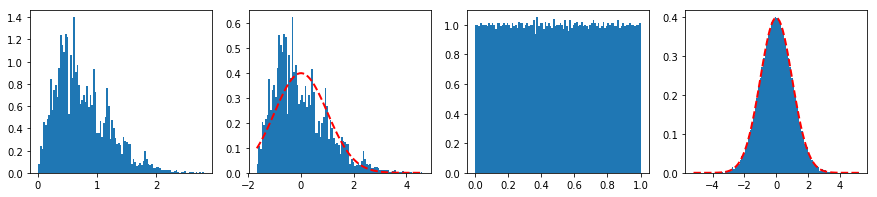

In [18]:
fig, axes = plt.subplots(1,4,figsize=(15,3))
_ = axes[0].hist(data_gen['redshift'], bins = 100, label = 'redshift', normed = True)
#_ = axes[1].hist(ellipticity_conversion(ellipticity_1), bins = 100, label = 'redshift', normed = True)
n, bins, patches = axes[1].hist(preprocessing.scale(data_gen['redshift']), bins = 100, label = 'redshift', normed = True)
(mu, sigma) = norm.fit(preprocessing.scale(data_gen['redshift']))
z_plt = mlab.normpdf( bins, mu, sigma)
axes[1].plot(bins, z_plt, 'r--', linewidth=2)

quantile_transformer = preprocessing.QuantileTransformer(random_state=0) 
X_train_trans = quantile_transformer.fit_transform(np.array(data_gen['redshift']).reshape(-1, 1))
n, bins, patches = axes[2].hist(X_train_trans, bins = 100, label = 'redshift', normed = True)

quantile_transformer = preprocessing.QuantileTransformer(output_distribution='normal',random_state=0) 
X_train_trans = quantile_transformer.fit_transform(np.array(data_gen['redshift']).reshape(-1, 1))
n, bins, patches = axes[3].hist(X_train_trans, bins = 100, label = 'redshift', normed = True)
(mu, sigma) = norm.fit(X_train_trans)
z_plt = mlab.normpdf( bins, mu, sigma)
axes[3].plot(bins, z_plt, 'r--', linewidth=2)

e1: -0.07403141773157887
e2: -0.02346957280460689
redshift: 0.906017071890128
SNR in r band: 51.29034806514481
e1: -0.010466069038850936
e2: 0.15806772864060498
redshift: 0.33514626007048953
SNR in r band: 56.50631603112294
e1: 0.060663659870877074
e2: -0.04781327335121127
redshift: 1.8151549919559369
SNR in r band: 57.32330362681763


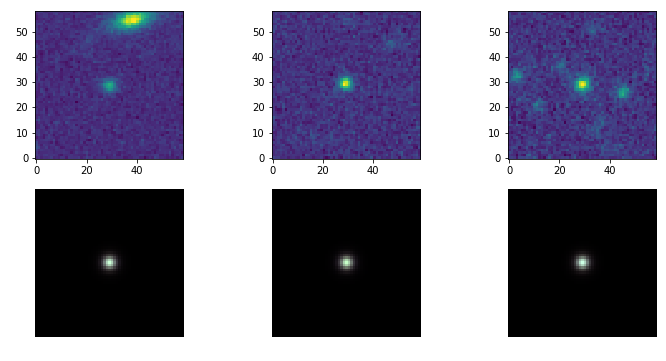

In [19]:
fig, axes  = plt.subplots(2,3, figsize = (12,6))
plus = 30

for i in range (3):
    # Image of galaxy scene
    img_gen[i+plus] -= np.min(img_gen[i+plus])
    axes[0,i].imshow(img_gen[i+plus,:,:,2], origin = 'lower')
    #plot.plot_rgb(img_gen[i+10]/np.max(img_gen[i+10]), bands=[4,3,1], ax=axes[0,i], band_first=False, zoom=1)
    # Corresponding PSF
    psf_gen[i+plus] -= np.min(psf_gen[i+plus])
    plot.plot_rgb(psf_gen[i+plus]/np.max(psf_gen[i+plus]), bands=[4,3,1], ax=axes[1,i], band_first=False, zoom=1)
    print('e1: '+str(data_gen['e1'][i+plus]))
    print('e2: '+str(data_gen['e2'][i+plus]))
    print('redshift: '+str(data_gen['redshift'][i+plus]))
    print('SNR in r band: '+str(data_gen['snr_r'][i+plus]))

In [20]:
quantile_transformer = preprocessing.QuantileTransformer(random_state=0) 
X_train_trans = quantile_transformer.fit(ellipticity_conversion(ellipticity_1).reshape(-1, 1))


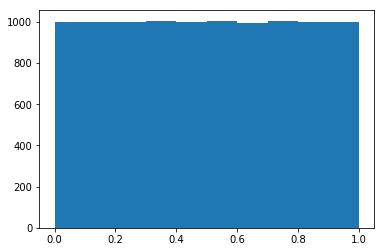

In [21]:
fig = plt.figure()
_ = plt.hist(X_train_trans.transform(ellipticity_conversion(ellipticity_1).reshape(-1, 1)))

In [22]:
img_gen.shape

(10000, 59, 59, 6)

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/pyplot.py:514: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


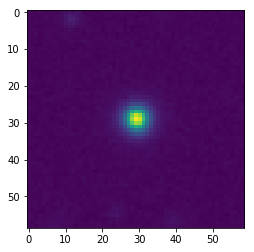

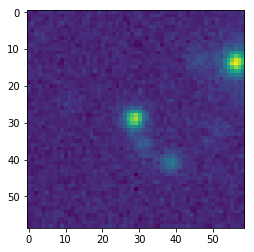

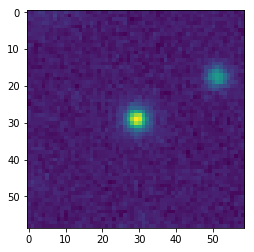

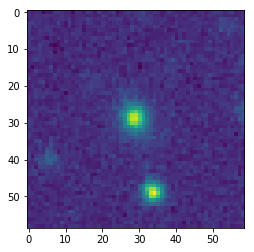

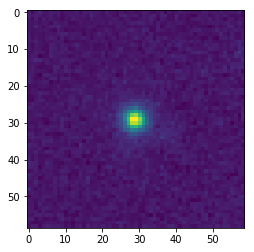

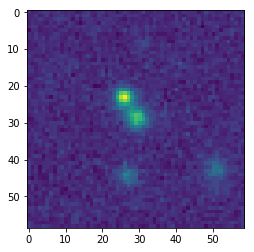

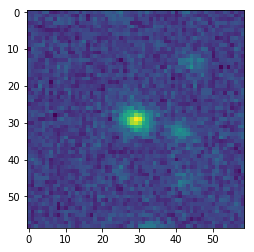

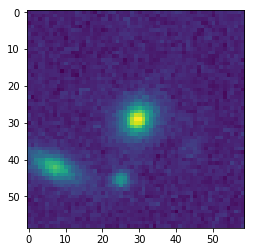

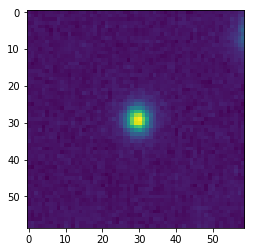

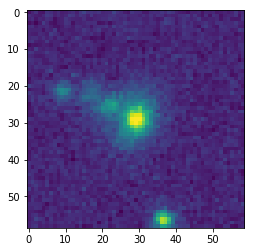

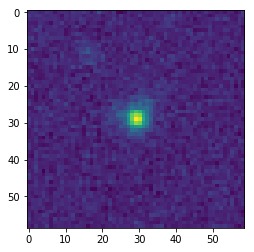

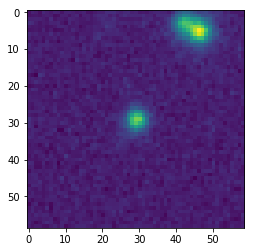

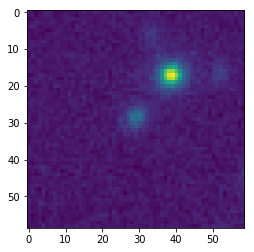

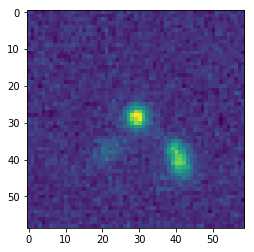

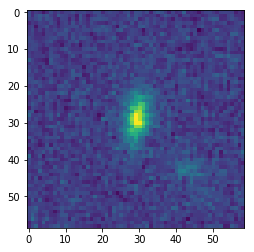

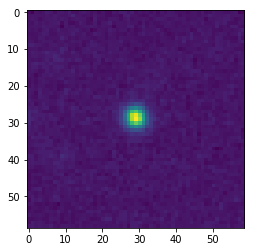

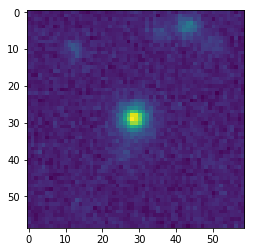

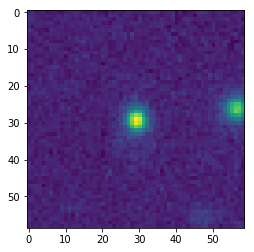

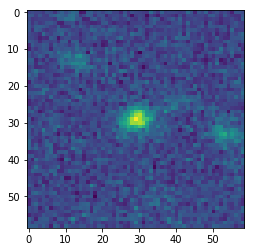

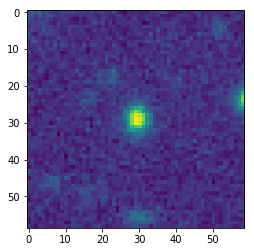

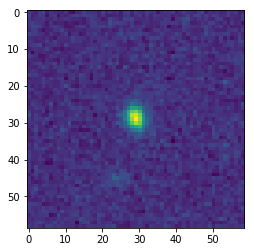

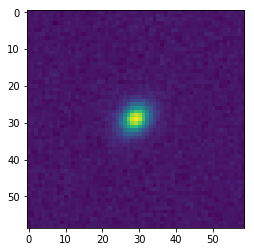

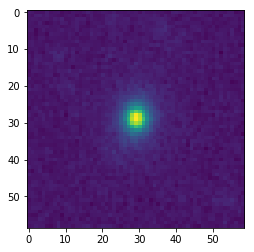

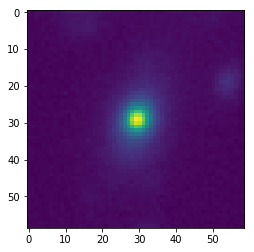

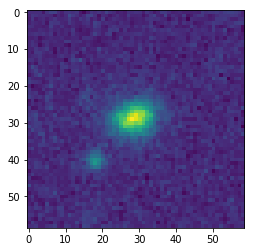

In [23]:
for i in range(25):
    fig = plt.figure()
    plt.imshow(img_gen[i,:,:,2])

Without ellipticity conversion

/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/ipykernel_launcher.py:6: MatplotlibDeprecationWarning: scipy.stats.norm.pdf
  
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'density'", removal="3.1")
/sps/lsst/users/barcelin/miniconda/envs/python_cpu6/lib/python3.6/site-packages/matplotlib/axes/_axes.py:6521: MatplotlibDeprecationWarning: 
The 'normed' kwarg was deprecated in Matplotlib 2.1 and will be removed in 3.1. Use 'density' instead.
  alternative="'densit

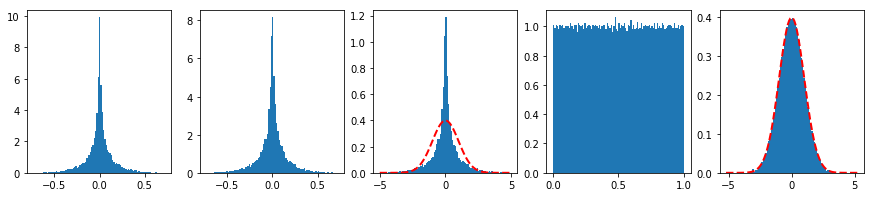

In [25]:
fig, axes = plt.subplots(1,5,figsize=(15,3))
_ = axes[0].hist(data_gen['e1'], bins = 100, label = 'e1', normed = True)
_ = axes[1].hist(ellipticity_1, bins = 100, label = 'e1', normed = True)
n, bins, patches = axes[2].hist(preprocessing.scale(ellipticity_1), bins = 100, label = 'e1', normed = True)
(mu, sigma) = norm.fit(preprocessing.scale(ellipticity_1))
z_plt = mlab.normpdf( bins, mu, sigma)
axes[2].plot(bins, z_plt, 'r--', linewidth=2)

quantile_transformer = preprocessing.QuantileTransformer(random_state=0) 
X_train_trans = quantile_transformer.fit_transform(ellipticity_1.reshape(-1, 1))
n, bins, patches = axes[3].hist(X_train_trans, bins = 100, label = 'e1', normed = True)

quantile_transformer = preprocessing.QuantileTransformer(output_distribution='normal',random_state=0) 
X_train_trans = quantile_transformer.fit_transform(ellipticity_1.reshape(-1, 1))
n, bins, patches = axes[4].hist(X_train_trans, bins = 100, label = 'e1', normed = True)
(mu, sigma) = norm.fit(X_train_trans)
z_plt = mlab.normpdf( bins, mu, sigma)
axes[4].plot(bins, z_plt, 'r--', linewidth=2)